# Plot: per-patient drug coefficient overview

Loads the direct per-patient drug-vs-DMSO coefficients from `2.per_patient_variate_importance.ipynb` (`results/per_patient_variate_importance/{organoid,single_cell}_per_patient_coefficients.parquet`) and plots every significant effect, faceted by patient.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/per_patient_variate_importance"
)
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/per_patient_variate_importance"
)

PVALUE_MAX = 0.05


def load_coefficients(profile_name):
    df = pd.read_parquet(
        results_path / f"{profile_name}_per_patient_coefficients.parquet"
    )
    df[["Compartment", "Channel", "Feature_type", "Measurement"]] = df[
        "feature"
    ].str.split("_", n=3, expand=True)
    df.loc[df["Feature_type"] == "AreaSizeShape", "Measurement"] = df["Channel"]
    df.loc[df["Feature_type"] == "AreaSizeShape", "Channel"] = None
    df["significant"] = df["pvalue_fdr"] < PVALUE_MAX
    return df


coef_dfs = {name: load_coefficients(name) for name in ["organoid", "single_cell"]}

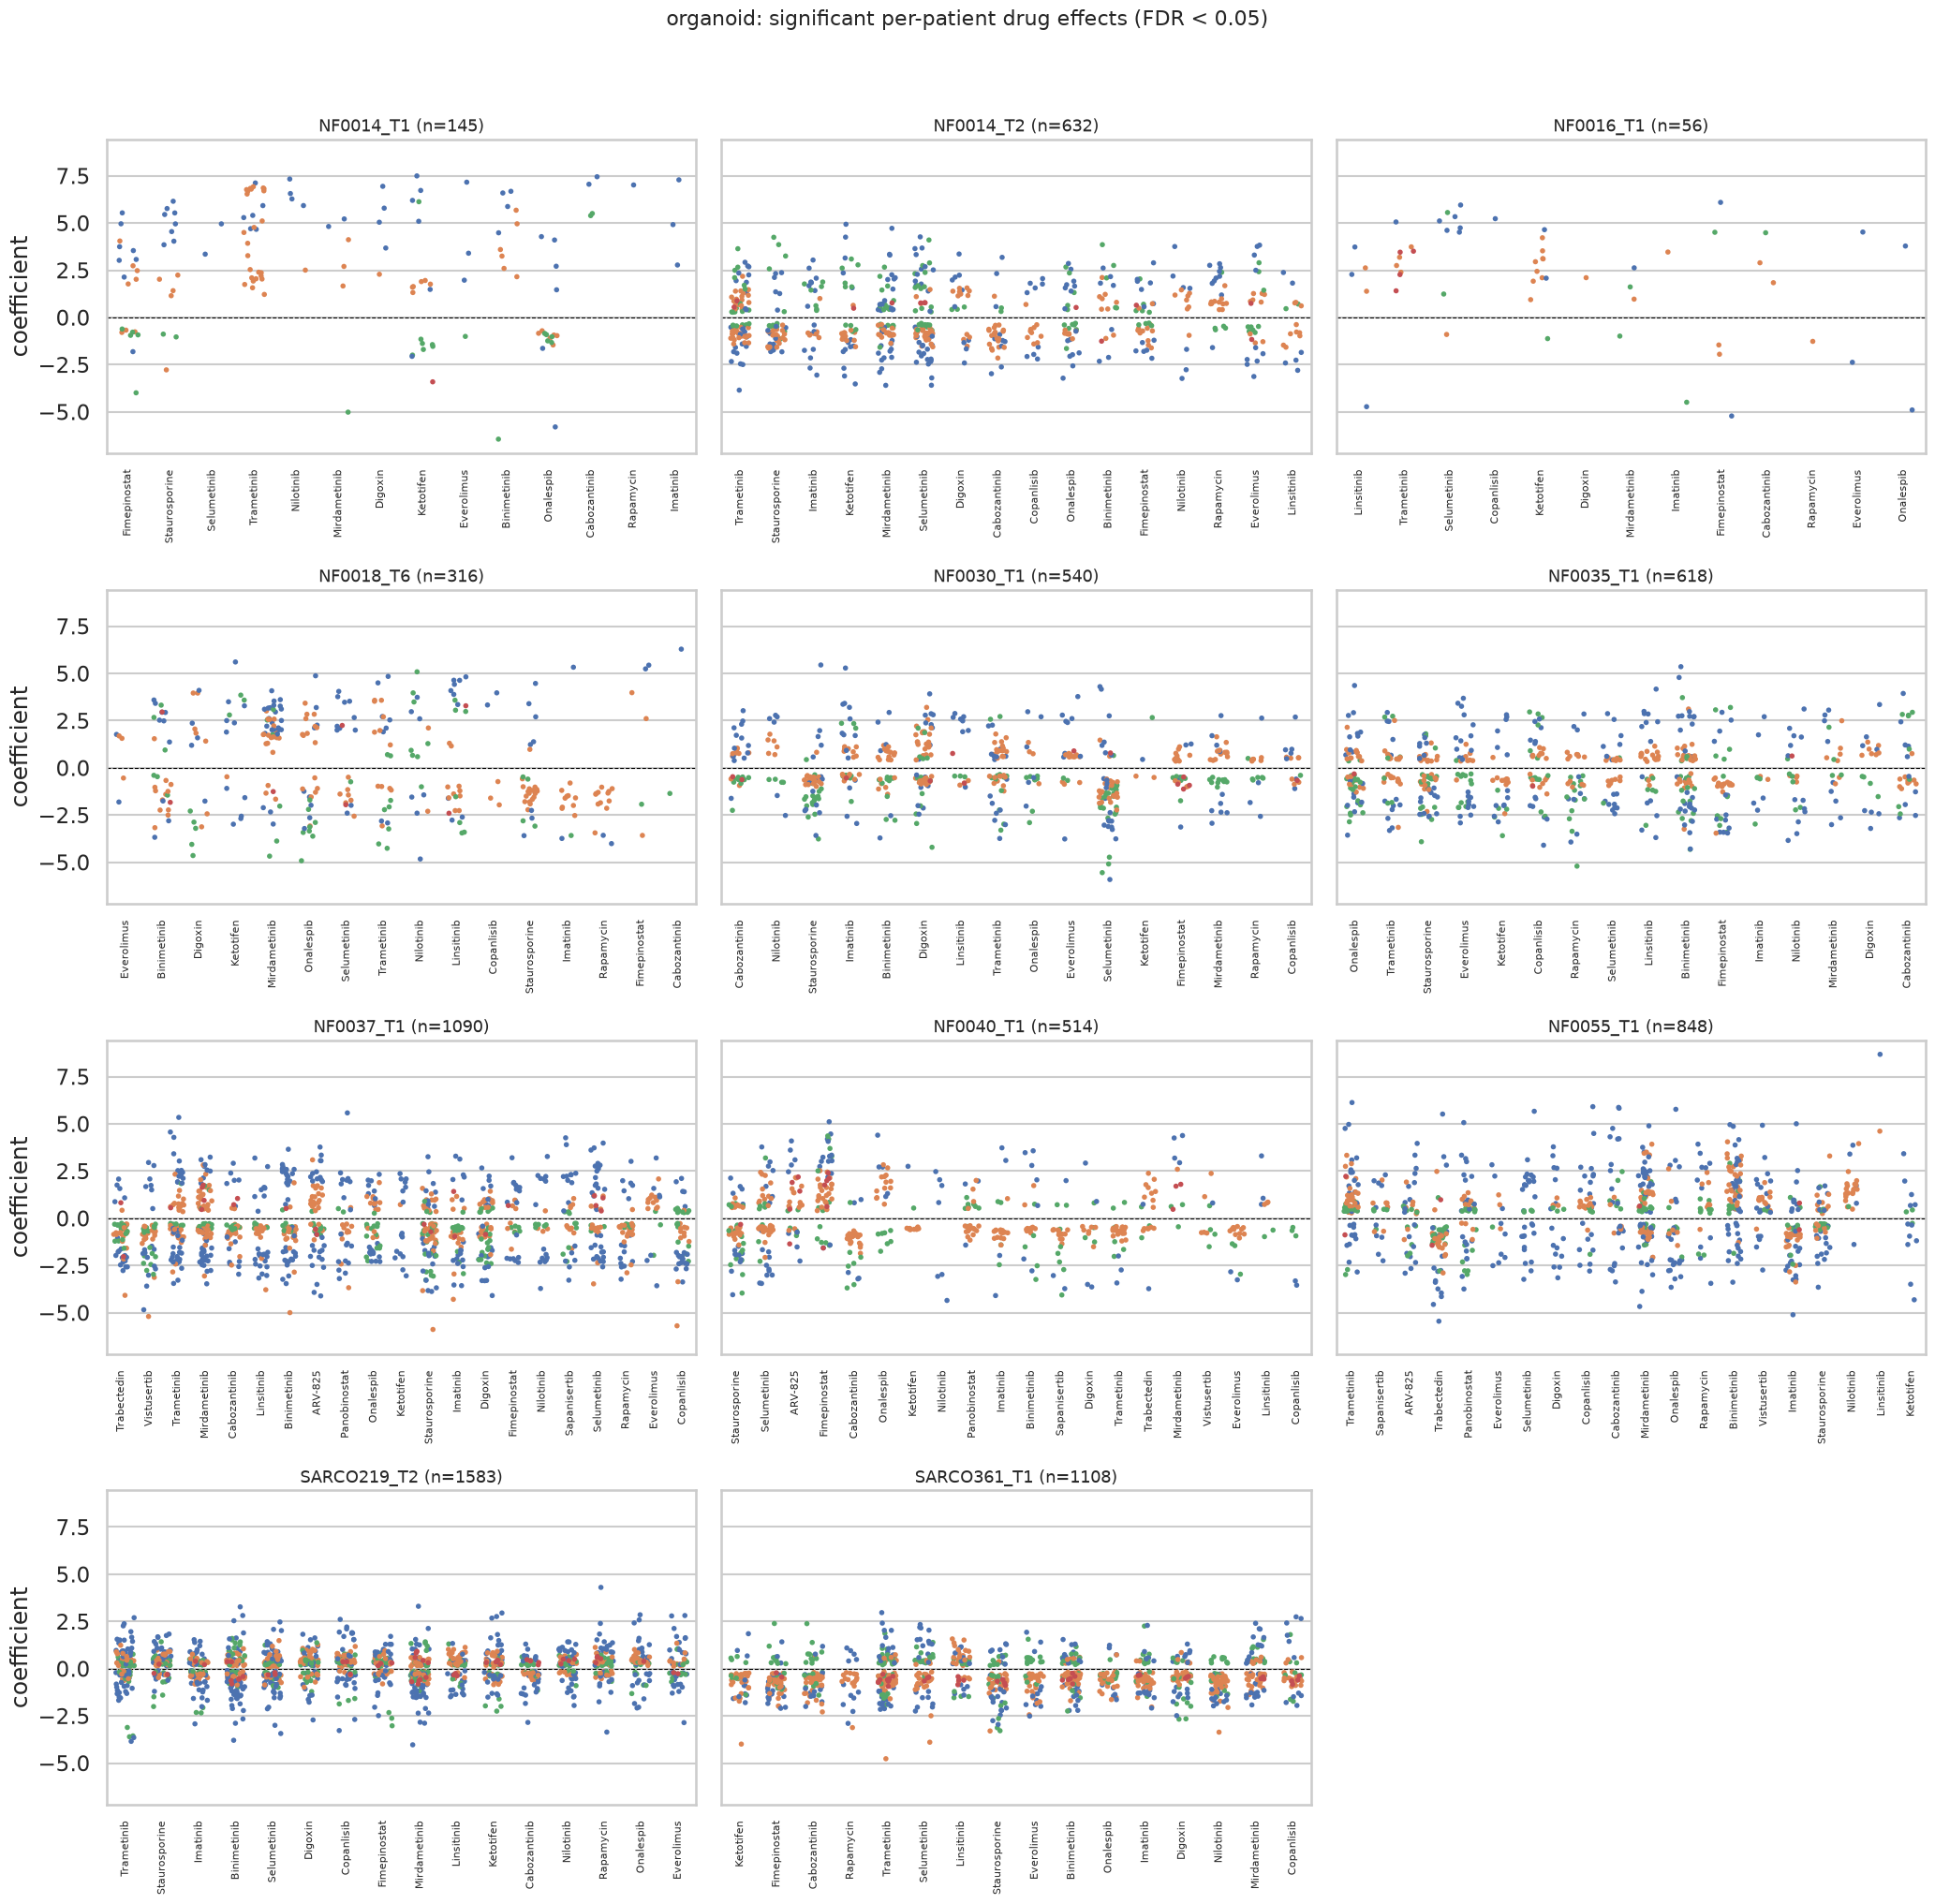


==== organoid: top significant effect per patient ====
           patient           drug  therapeutic_category  \
2865     NF0014_T1      Ketotifen  Anti-Allergic Agents   
4285     NF0014_T2      Ketotifen  Anti-Allergic Agents   
8977     NF0016_T1   Fimepinostat       Investigational   
12231    NF0018_T6   Cabozantinib      Kinase Inhibitor   
18773    NF0030_T1    Selumetinib      Kinase Inhibitor   
21245    NF0035_T1    Binimetinib      Kinase Inhibitor   
25335    NF0037_T1  Staurosporine          Experimental   
26795    NF0040_T1   Fimepinostat       Investigational   
30785    NF0055_T1     Linsitinib       Investigational   
36991  SARCO219_T2      Rapamycin      Kinase Inhibitor   
39006  SARCO361_T1     Trametinib      Kinase Inhibitor   

                                       feature  coefficient    pvalue_fdr  \
2865               Organoid_Mito_Granularity_8     7.494380  9.671514e-05   
4285               Organoid_DNA_Granularity_15     4.934954  2.957066e-10   
8977

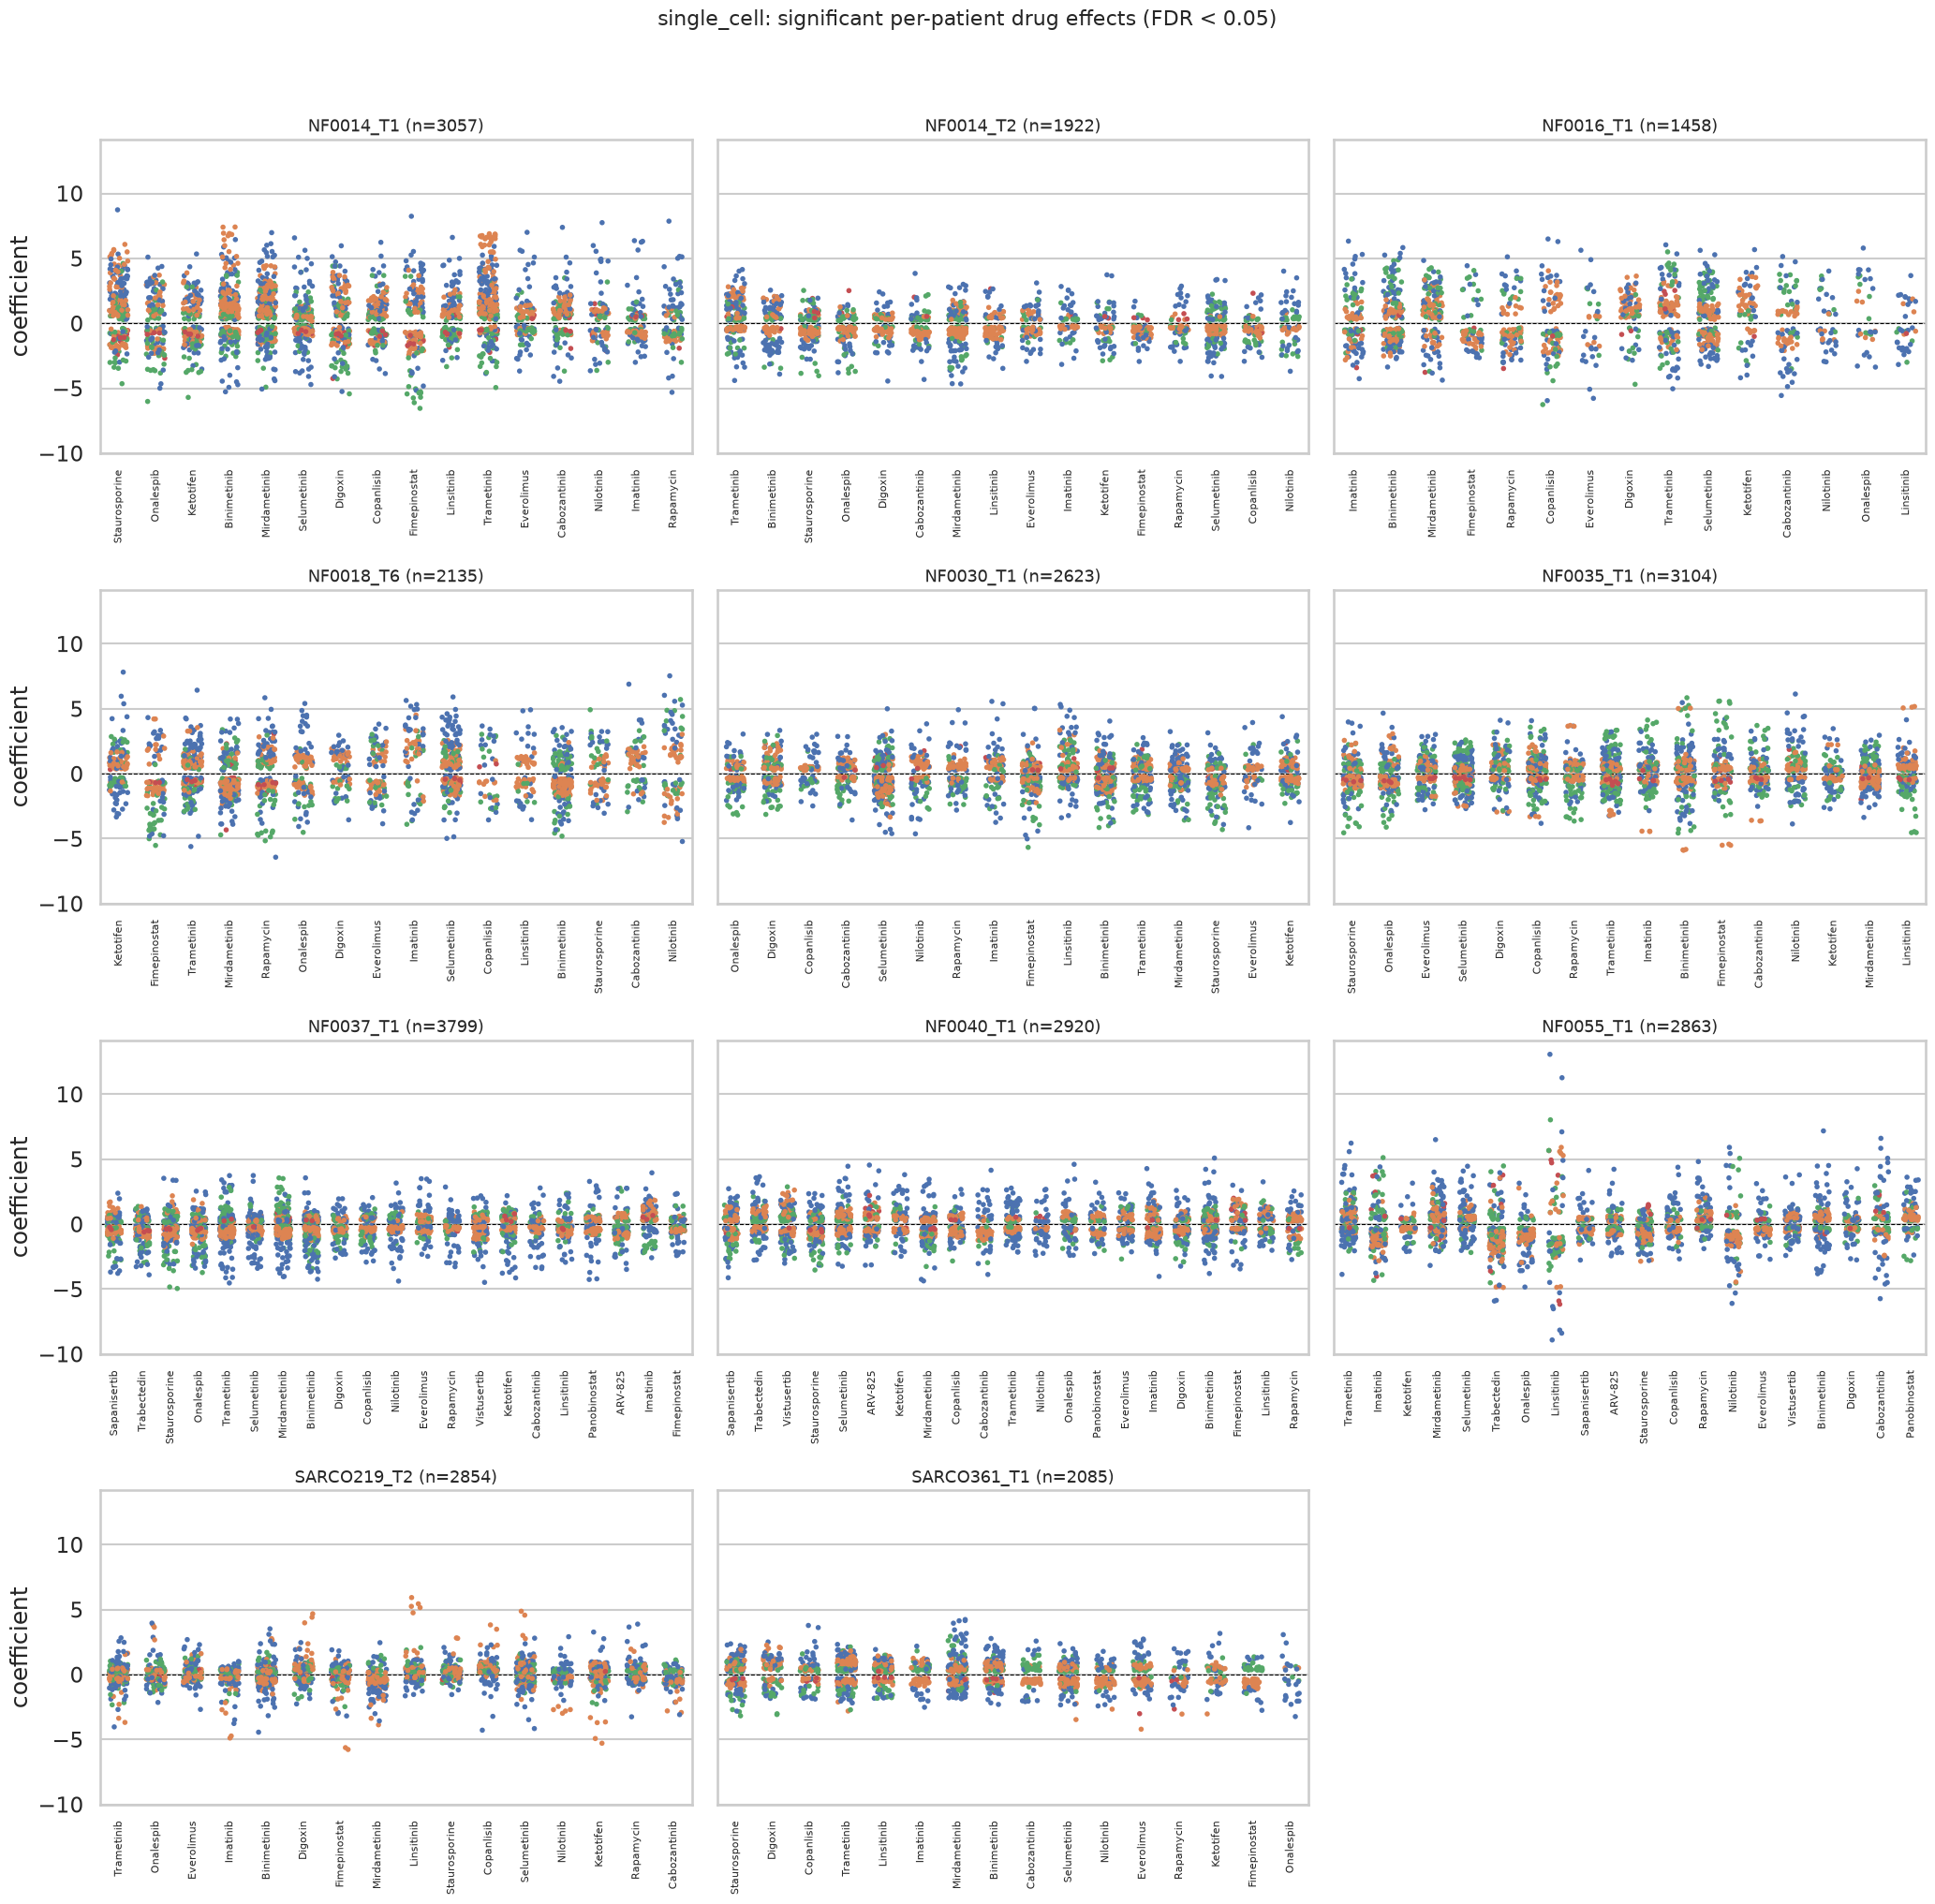


==== single_cell: top significant effect per patient ====
           patient           drug  therapeutic_category  \
2861     NF0014_T1  Staurosporine          Experimental   
8047     NF0014_T2   Mirdametinib      Kinase Inhibitor   
13846    NF0016_T1     Copanlisib      Kinase Inhibitor   
18867    NF0018_T6      Ketotifen  Anti-Allergic Agents   
30233    NF0030_T1   Fimepinostat       Investigational   
34097    NF0035_T1      Nilotinib       Investigational   
41448    NF0037_T1  Staurosporine          Experimental   
49053    NF0040_T1    Binimetinib      Kinase Inhibitor   
56138    NF0055_T1     Linsitinib       Investigational   
59651  SARCO219_T2     Linsitinib       Investigational   
67150  SARCO361_T1   Mirdametinib      Kinase Inhibitor   

                                                 feature  coefficient  \
2861                       Cytoplasm_Mito_Granularity_16     8.736476   
8047                          Cytoplasm_ER_Granularity_7    -4.664479   
13846        

In [2]:
def plot_coefficient_overview(df, name):
    sig = df[df["significant"]].copy()
    patients = sorted(sig["patient"].unique())
    n_cols = 3
    n_rows = int(np.ceil(len(patients) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), sharey=True
    )
    axes = np.array(axes).reshape(-1)
    for ax, patient in zip(axes, patients):
        pdf = sig[sig["patient"] == patient]
        sns.stripplot(
            data=pdf,
            x="drug",
            y="coefficient",
            hue="Feature_type",
            ax=ax,
            size=4,
            jitter=0.25,
            legend=False,
        )
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{patient} (n={len(pdf)})", fontsize=13)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=90, labelsize=8)
    for ax in axes[len(patients) :]:
        ax.axis("off")
    fig.suptitle(
        f"{name}: significant per-patient drug effects (FDR < {PVALUE_MAX})",
        y=1.02,
        fontsize=16,
    )
    plt.tight_layout()
    plt.savefig(
        figures_path / f"{name}_coefficient_overview_by_patient.png",
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()


for name, df in coef_dfs.items():
    plot_coefficient_overview(df, name)
    sig = df[df["significant"]].copy()
    sig["abs_coefficient"] = sig["coefficient"].abs()
    top = sig.sort_values("abs_coefficient", ascending=False).groupby("patient").head(1)
    print(f"\n==== {name}: top significant effect per patient ====")
    print(
        top[
            [
                "patient",
                "drug",
                "therapeutic_category",
                "feature",
                "coefficient",
                "pvalue_fdr",
                "rsquared",
            ]
        ].sort_values("patient")
    )